In [309]:
'''
The objetive of this code is to obtain accurate 1D plots and azimuthal integration of data collected from Maxima. Ideally, 
the code should run such that the processing of the data keeps up with the acquisition rate of the data. 

We intend to do this with tools provided by PyFAI. The typical streamlined process advertised on the PyFAI website suggests 
methods that involve user interaction for the selection and confirmation of the debye-scherrer rings. To streamline this 
process, we have the user first extract the beam center, rotation of the detector relative to the beam and the sample-to-
detector distance for an alpha alumina calibrant using the PyFAI GUI. The diffraction pattern should be collected at the 
same sample-to-detector distance as the alpha alumina calibrants in the experiment. We then use a tool from PyFAI to refit
these parameters to those of the alpha alumina calibrants in the specimen holder.

With confirmation that the specimen is perpendicular to the beam, the code uses the average of the parameters from the .poni
files of each of the calibrants to use as the new experimental setup. With the calibration complete, the remaining code takes
the 1D diffraction patterns and the azimuthal integration of every tiff in the folder and saves it to the folder "my_plots."
'''

'\nThe objetive of this code is to obtain accurate 1D plots and azimuthal integration of data collected from Maxima. Ideally, \nthe code should run such that the processing of the data keeps up with the acquisition rate of the data. \n\nWe intend to do this with tools provided by PyFAI. The typical streamlined process advertised on the PyFAI website suggests \nmethods that involve user interaction for the selection and confirmation of the debye-scherrer rings. To streamline this \nprocess, we have the user first extract the beam center, rotation of the detector relative to the beam and the sample-to-\ndetector distance for an alpha alumina calibrant using the PyFAI GUI. The diffraction pattern should be collected at the \nsame sample-to-detector distance as the alpha alumina calibrants in the experiment. We then use a tool from PyFAI to refit\nthese parameters to those of the alpha alumina calibrants in the specimen holder.\n\nWith confirmation that the specimen is perpendicular to the

In [310]:
## Expected Peaks

peak_1 = 3.009
# peak_2 = 0

In [311]:
## GO BACK AND CHECK THESE LATER



## Below we import all functions we expect to use.

from matplotlib.pyplot import subplots
from pyFAI.gui import jupyter
import pyFAI
import fabio
from pyFAI.test.utilstest import UtilsTest
from pyFAI.calibrant import CALIBRANT_FACTORY
import pyFAI.calibrant
import matplotlib.pyplot as plt
import numpy as np
from pyFAI.goniometer import SingleGeometry
print(f"Using pyFAI version: {pyFAI.version}")

%matplotlib inline
# use `widget` for better user user experience; `inline` is for documentation generation

Using pyFAI version: 2024.9.0


In [312]:
## Collect a diffraction pattern from one of the calibrants at the desired distance for the upcoming experiment. Then go through
## the PyFAI GUI steps and generate both the mask file and the .poni file. Upload them here.

Calib_poni_file = "5_4-2025_Calibrant.poni"
Calib_tiff_file = "scan_point_5.tiff"
Initial_Calibrant = pyFAI.load(Calib_poni_file)
Mask_File = '5_4_2025_mask.edf'
Mask_Region = fabio.open(Mask_File).data

Back_File = 'background.tiff'
Back_Sub = fabio.open(Back_File).data 


print(Initial_Calibrant)
print(Mask_Region)

Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.123314e-11 m
SampleDetDist= 9.451165e-02 m	PONI= 4.022422e-02, 3.797950e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.520 mm	Center: x=517.947, y=524.498 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.512Å
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [313]:
## Run the subsequent tests, collecting diffraction patterns of each alpha alumina calibrant at the start. Then drop the
## calibration files and all diffraction patterns collected from specimens attached to this holder into the same folder as this
## jupyter notebook. Indicate the calibration files below, the wavelength of the incident beam, and the type of detector. Lastly,
## include the distance between the beam-to-detector distance of the sample and that of the calibrants in meters.

North = "scan_point_5.tiff"
East = "scan_point_6.tiff"
South = "scan_point_7.tiff"
West = "scan_point_8.tiff"

wavelength = 0.5134e-10 #0.5134e-10

eiger = pyFAI.detector_factory("eiger2cdte1m")
# eiger

Al2O3 = CALIBRANT_FACTORY("alpha_Al2O3")
Al2O3.wavelength = wavelength

beam_to_detector_offset = -3.45e-3 #4.512*10e-4

In [314]:
## Please indicate what kind of data you would like at the end. Indicate which of the features you would like with a "yes" or a
## "no" for background subtraction and masking. For plot_style, indicate whether you want just the 1D plot with "1D", just the 
## 2D plot with "2D", or both with "both". If you want to check the calibrant, switch it to "yes", see how well the calibrant
## file lines up with the peaks, and then run again after setting it to "no" when saving the data.

background_subtraction = "no"
masking = "yes"
plot_style = "1D"

show_calibrant = "yes"
Output_text = "yes"


In [315]:
North_Calibrant = fabio.open(North).data
East_Calibrant = fabio.open(East).data
South_Calibrant = fabio.open(South).data
West_Calibrant = fabio.open(West).data

ControlPoints instance containing 15 group of point:
alpha_Al2O3 Calibrant with 31 reflections at wavelength 5.134e-11
Containing 15 groups of points:
#aib ring 0: 338 points
#aic ring 1: 344 points
#aid ring 2: 346 points
#aie ring 3: 348 points
#aif ring 4: 348 points
#aig ring 5: 350 points
#aih ring 6: 350 points
#aii ring 7: 350 points
#aij ring 8: 352 points
#aik ring 9: 352 points
#ail ring 10: 352 points
#aim ring 11: 352 points
#ain ring 12: 353 points
#aio ring 13: 341 points
#aip ring 14: 253 points

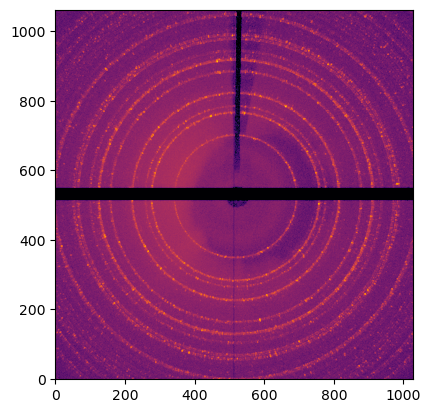

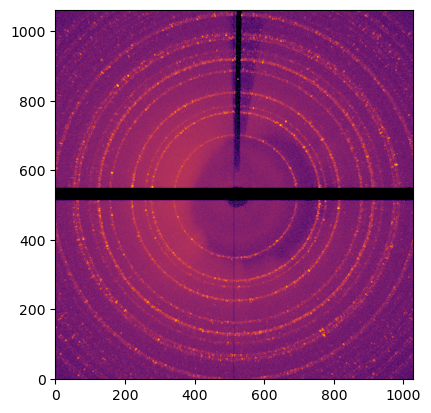

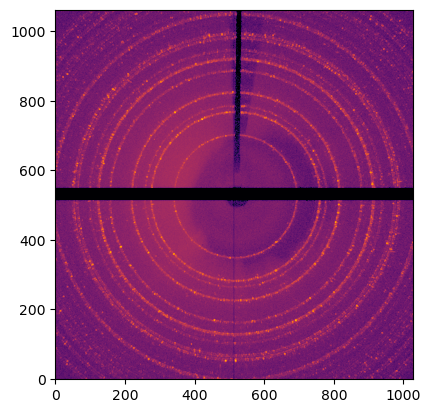

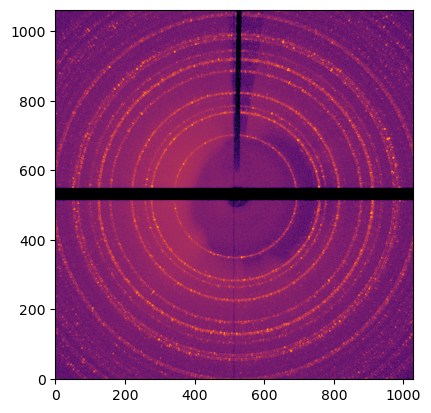

In [316]:
jupyter.display(North_Calibrant)
jupyter.display(East_Calibrant)
jupyter.display(South_Calibrant)
jupyter.display(West_Calibrant)

sg1 = SingleGeometry("Comparison of North with Standard Al2O3", image=North_Calibrant, calibrant=Al2O3, detector=eiger, geometry=Initial_Calibrant)
sg1.extract_cp(max_rings=15)

sg2 = SingleGeometry("Comparison of East with Standard Al2O3", image=East_Calibrant, calibrant=Al2O3, detector=eiger, geometry=Initial_Calibrant)
sg2.extract_cp(max_rings=15)

sg3 = SingleGeometry("Comparison of South with Standard Al2O3", image=South_Calibrant, calibrant=Al2O3, detector=eiger, geometry=Initial_Calibrant)
sg3.extract_cp(max_rings=15)

sg4 = SingleGeometry("Comparison of West with Standard Al2O3", image=West_Calibrant, calibrant=Al2O3, detector=eiger, geometry=Initial_Calibrant)
sg4.extract_cp(max_rings=15)

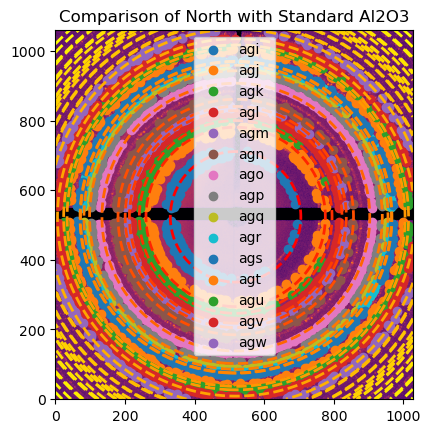

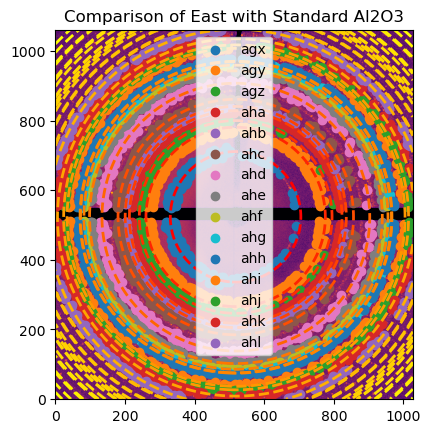

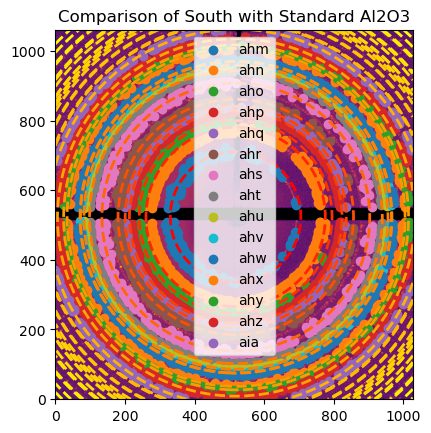

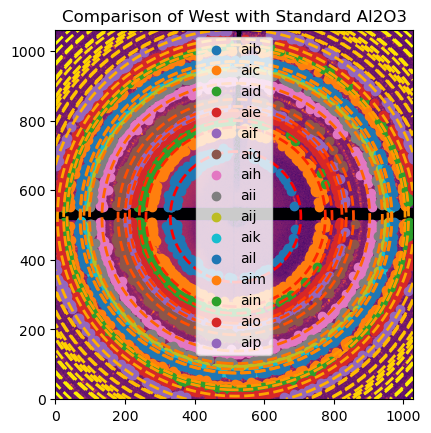

In [317]:
## Find points based on initial guess of rings and peakfinding.

ax = jupyter.display(sg=sg1)
ax = jupyter.display(sg=sg2)
ax = jupyter.display(sg=sg3)
ax = jupyter.display(sg=sg4)

In [318]:
## Refine the geometry for each of our calibrants. 

sg1.geometry_refinement.refine2(fix=["rot1", "rot2", "rot3", "wavelength"])
ai1 = sg1.get_ai()

sg2.geometry_refinement.refine2(fix=["rot1", "rot2", "rot3", "wavelength"])
ai2 = sg2.get_ai()

sg3.geometry_refinement.refine2(fix=["rot1", "rot2", "rot3", "wavelength"])
ai3 = sg3.get_ai()

sg4.geometry_refinement.refine2(fix=["rot1", "rot2", "rot3", "wavelength"])
ai4 = sg4.get_ai()

print(ai1)
print(ai2)
print(ai3)
print(ai4)

Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.452309e-02 m	PONI= 4.022591e-02, 3.795866e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.531 mm	Center: x=517.671, y=524.519 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å
Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.446495e-02 m	PONI= 4.023235e-02, 3.795783e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.473 mm	Center: x=517.652, y=524.612 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å
Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.446476e-02 m	PONI= 4.022224e-02, 3.794647e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.473 mm	Center: x=517.501, y=524.477 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å
Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomR

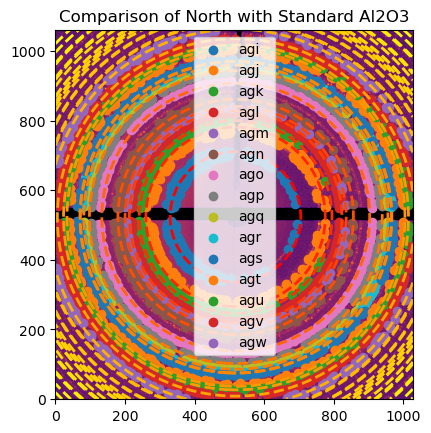

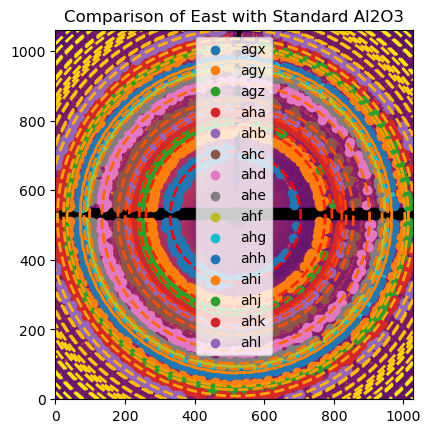

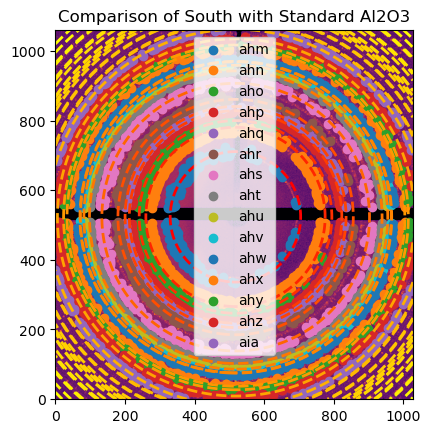

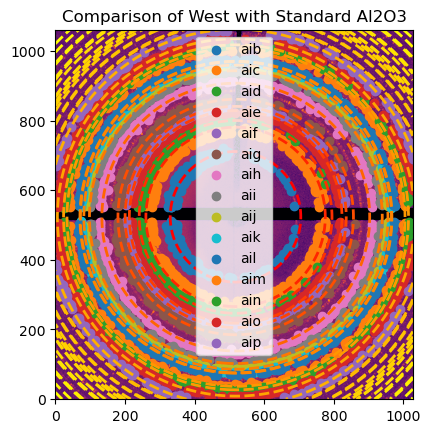

In [319]:
## Here is a visual of the newly fitted calibrants for each direction. This will
## be used more as a check in case the user is unsatisfied with the calibration
## parameters obtained from the last step.

ax = jupyter.display(sg=sg1)
ax = jupyter.display(sg=sg2)
ax = jupyter.display(sg=sg3)
ax = jupyter.display(sg=sg4)

In [320]:
## If satisfied, save the geometry from each calibrant as it's own .poni file
## and continue to work with those parameters.

ai1.save("geometry_North.poni")
ai2.save("geometry_East.poni")
ai3.save("geometry_South.poni")
ai4.save("geometry_West.poni")

print(ai1)
print(ai2)
print(ai3)
print(ai4)

Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.452309e-02 m	PONI= 4.022591e-02, 3.795866e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.531 mm	Center: x=517.671, y=524.519 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å
Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.446495e-02 m	PONI= 4.023235e-02, 3.795783e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.473 mm	Center: x=517.652, y=524.612 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å
Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.446476e-02 m	PONI= 4.022224e-02, 3.794647e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.473 mm	Center: x=517.501, y=524.477 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å
Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomR

In [321]:
## Create a new .poni file that takes averages across the parameters of each of the calibrants

## Go back and make it such that the original .poni file angle tilts are accounted for here instead of using these ones-- check with Michael

sample_to_detector_distance_North = ai1.dist
sample_to_detector_distance_East = ai2.dist
sample_to_detector_distance_South = ai3.dist
sample_to_detector_distance_West = ai4.dist
# print(sample_to_detector_distance_North)
# print(sample_to_detector_distance_East)
# print(sample_to_detector_distance_South)
# print(sample_to_detector_distance_West)

Averaged_dist = ((sample_to_detector_distance_North+sample_to_detector_distance_East+sample_to_detector_distance_South+sample_to_detector_distance_West)/4) + beam_to_detector_offset

# print(Averaged_dist)

x_val_North = ai1.poni2 / ai1.pixel2
y_val_North = ai1.poni1 / ai1.pixel1
x_val_East = ai2.poni2 / ai2.pixel2
y_val_East = ai2.poni1 / ai2.pixel1
x_val_South = ai3.poni2 / ai3.pixel2
y_val_South = ai3.poni1 / ai3.pixel1
x_val_West = ai4.poni2 / ai4.pixel2
y_val_West = ai4.poni1 / ai4.pixel1


Average_x = (x_val_North+x_val_East+x_val_South+x_val_West)/4
Average_y = (y_val_North+y_val_East+y_val_South+y_val_West)/4

# print(Average_x)
# print(Average_y)


# print(ai1.poni1 / ai1.pixel1)
# print(ai1.poni2 / ai1.pixel2)



# Set the guessed geometry
combined = pyFAI.geometry.Geometry(detector=eiger, wavelength=wavelength)
combined.setFit2D(Averaged_dist*1000,Average_x,Average_y)
combined

combined.rot1 = Initial_Calibrant.rot1
combined.rot2 = Initial_Calibrant.rot2
combined.rot3 = Initial_Calibrant.rot3

combined.save("my_geometry.ai")

In [322]:
print(combined)

Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.104416e-02 m	PONI= 4.022804e-02, 3.795696e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 91.052 mm	Center: x=517.223, y=524.982 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å


In [323]:
ai_calibrants = pyFAI.load("my_geometry.ai")
ai_calibrants.dist = ((sample_to_detector_distance_North+sample_to_detector_distance_East+sample_to_detector_distance_South+sample_to_detector_distance_West)/4)
ai_calibrants.save("calibrants.ai")

print(ai_calibrants)

Detector Eiger2 CdTe 1M	 PixelSize= 75µm, 75µm	 BottomRight (3)
Wavelength= 5.134000e-11 m
SampleDetDist= 9.449416e-02 m	PONI= 4.022804e-02, 3.795696e-02 m	rot1=-0.009168  rot2=-0.009383  rot3=0.000000 rad
DirectBeamDist= 94.502 mm	Center: x=517.644, y=524.551 pix	Tilt= 0.752° tiltPlanRotation= -45.665° 𝛌= 0.513Å


In [324]:
## Use the combined .poni as the accepted geometry of our series of experiments.
## Place all .tiff files from the recent series of diffraction patterns in this
## folder and run these steps.

## The following code accesses all .tiff files and processe them to generate
## 1D integration and 2D integration plots. These figures are saved as .pngs

import glob
import os

folder_path = os.getcwd()

print(folder_path)

tiff_files = glob.glob(os.path.join(folder_path, "*.tiff"))  # Use "*.tif" if needed



C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28


In [325]:
## Run this code for 1D and 2D azimuthal integration

## This code creates a folder called my_plots if the folder does not exist.
## It then performs the 1D and 2D azimuthal integrations for each file and
## saves it as a PNG file in the folder using it's original name. DO NOT
## remove the step of saving the file under the folder my_plots. It WILL
## overwrite the original TIFF files. Save the data files elsewhere as a
## backup in case the files get overwritten in the folder with the jupyter
## code.

folder_path = "my_plots"
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    
ai_loaded = pyFAI.load("my_geometry.ai")
ai_calibrated = pyFAI.load("calibrants.ai")




for i in range(len(tiff_files)):
    image = fabio.open(tiff_files[i]).data
    first_title = os.path.basename(tiff_files[i])
    jupyter.display(image)

        
    if first_title == Calib_tiff_file or first_title == North or tiff_files[i] == East or first_title == South or first_title == West:
        
        fig, ax = subplots(1, 2, figsize=(10, 5))      
        
        jupyter.plot1d(ai_calibrated.integrate1d(image, 1000), ax=ax[0], calibrant=Al2O3)
        jupyter.plot2d(ai_calibrated.integrate2d(image,1000), ax=ax[1], calibrant=Al2O3)
        _ = ax[1].set_title("2D integration")
        
        
    else:
        
        if plot_style == "both":
            fig, ax = subplots(1, 2, figsize=(10, 5))        

            if background_subtraction == "yes":
                if masking == "yes":

                    jupyter.plot1d(ai_loaded.integrate1d(image - Back_Region, 1000, mask=Mask_Region), ax=ax[0])
                    jupyter.plot2d(ai_loaded.integrate2d(image - Back_Region,1000, mask=Mask_Region), ax=ax[1])
                    _ = ax[1].set_title("2D integration")


                elif masking == "no":

                    jupyter.plot1d(ai_loaded.integrate1d(image - Back_Region, 1000), ax=ax[0])
                    jupyter.plot2d(ai_loaded.integrate2d(image - Back_Region,1000), ax=ax[1])
                    _ = ax[1].set_title("2D integration")


            elif background_subtraction == "no":
                if masking == "yes":

                    jupyter.plot1d(ai_loaded.integrate1d(image, 1000, mask=Mask_Region), ax=ax[0])
                    jupyter.plot2d(ai_loaded.integrate2d(image,1000, mask=Mask_Region), ax=ax[1])
                    _ = ax[1].set_title("2D integration")

                elif masking == "no":

                    jupyter.plot1d(ai_loaded.integrate1d(image, 1000), ax=ax[0])
                    jupyter.plot2d(ai_loaded.integrate2d(image,1000), ax=ax[1])
                    _ = ax[1].set_title("2D integration")





        elif plot_style == "1D":

            plt.figure()       

            if background_subtraction == "yes":
                if masking == "yes":
                    
                    jupyter.plot1d(ai_loaded.integrate1d(image - Back_Region, 1000, mask=Mask_Region))

                elif masking == "no":

                    jupyter.plot1d(ai_loaded.integrate1d(image - Back_Region, 1000))

            elif background_subtraction == "no":
                if masking == "yes":

                    jupyter.plot1d(ai_loaded.integrate1d(image, 1000, mask=Mask_Region))

                elif masking == "no":

                    jupyter.plot1d(ai_loaded.integrate1d(image, 1000))






        elif plot_style == "2D":

            plt.figure()       

            if background_subtraction == "yes":
                if masking == "yes":
                        
                    jupyter.plot2d(ai_loaded.integrate2d(image - Back_Region, 1000, mask=Mask_Region))

                elif masking == "no":

                    jupyter.plot2d(ai_loaded.integrate2d(image - Back_Region, 1000))


            elif background_subtraction == "no":
                if masking == "yes":
                        
                    jupyter.plot2d(ai_loaded.integrate2d(image, 1000, mask=Mask_Region))

                elif masking == "no":

                    jupyter.plot2d(ai_loaded.integrate2d(image, 1000))


        else:

            print("Indicate what type of plot you want")
            continue


    temp_title = first_title.rstrip(".tiff")
    temp_path = tiff_files[i].rstrip(first_title)
#     print(temp_path)
    
    file_path = os.path.join(temp_path, folder_path)
#     print(file_path)
    
    final_path = os.path.join(file_path, temp_title)
#     print(final_path)
    
    
    plt.savefig(final_path, dpi=300) # Save as high-resolution PNG
    
    image_path = os.path.join(file_path, first_title)
    
    if background_subtraction == "no":
    
        plt.imsave(image_path, image)
        
    elif background_subtraction == "yes":
        
        plt.imsave(image_path, image - Back_Sub)
        
    text_title = temp_title + '.txt'
    text_path = os.path.join(file_path, text_title)
    
    print(temp_path)
    print(text_path)
        
    if Output_text == "yes":
        (x, y) = ai_loaded.integrate1d(image, 1000)
#         print(x)
#         print(y)
        
        data = np.column_stack((x, y))

        np.savetxt(text_path, data, header="2theta\tIntensity", fmt='%.6e', delimiter='\t')



    
    plt.close('all')

C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\my_plots\background.txt
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\my_plots\scan_point_0.txt
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\my_plots\scan_point_1.txt
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\my_plots\scan_point_2.txt
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\
C:\Users\alexd\Downloads\Processing_Data_5_16_2025\Complete_Maxima_Code_2025_02_28\my_plots\scan_point_3.txt
C:\Users\alexd\Downloads\Processing_D

In [326]:
# ## Run this code for 1D and 2D azimuthal integration

# ## This code creates a folder called my_plots if the folder does not exist.
# ## It then performs the 1D and 2D azimuthal integrations for each file and
# ## saves it as a PNG file in the folder using it's original name. DO NOT
# ## remove the step of saving the file under the folder my_plots. It WILL
# ## overwrite the original TIFF files. Save the data files elsewhere as a
# ## backup in case the files get overwritten in the folder with the jupyter
# ## code.

# folder_path = "my_plots"
# if not os.path.exists(folder_path):
#     os.makedirs(folder_path)
    
# ai_loaded = pyFAI.load("my_geometry.ai")
    
# for i in range(len(tiff_files)):
#     image = fabio.open(tiff_files[i]).data
#     jupyter.display(image)
#     res1 = ai_loaded.integrate1d(image, 1000)
#     res2 = ai_loaded.integrate2d(image,1000)
    
#     ## Plotting both
    
#     fig, ax = subplots(1, 2, figsize=(10, 5))
#     jupyter.plot1d(res1, ax=ax[0])
#     jupyter.plot2d(res2, ax=ax[1])
#     _ = ax[1].set_title("2D integration")
        
        
#     ## Plotting 1D
    
# #     plt.figure()
# #     jupyter.plot1d(ai_loaded.integrate1d(image, 1000))
        
# #     ## Plotting 2D
    
# #     plt.figure()
# #     jupyter.plot2d(ai_loaded.integrate2d(image, 1000))

#     first_title = os.path.basename(tiff_files[i])
#     temp_title = first_title.rstrip(".tiff")
#     temp_path = tiff_files[i].rstrip(first_title)
#     print(temp_path)
    
#     file_path = os.path.join(temp_path, folder_path)
# #     print(file_path)
    
#     final_path = os.path.join(file_path, temp_title)
#     print(final_path)
    
    
#     plt.savefig(final_path, dpi=300) # Save as high-resolution PNG
    
#     image_path = os.path.join(file_path, first_title)
#     plt.imsave(image_path, image)
    
#     plt.close('all')


In [327]:
# ## Run this code for 1D and 2D azimuthal integration

# ## This code creates a folder called my_plots if the folder does not exist.
# ## It then performs the 1D and 2D azimuthal integrations for each file and
# ## saves it as a PNG file in the folder using it's original name. DO NOT
# ## remove the step of saving the file under the folder my_plots. It WILL
# ## overwrite the original TIFF files. Save the data files elsewhere as a
# ## backup in case the files get overwritten in the folder with the jupyter
# ## code.

# folder_path = "my_plots"
# if not os.path.exists(folder_path):
#     os.makedirs(folder_path)
    
# ai_loaded = pyFAI.load("my_geometry.ai")
    
# for i in range(len(tiff_files)):
#     image = fabio.open(tiff_files[i]).data
#     jupyter.display(image)
#     res1 = ai_loaded.integrate1d(image, 1000)
#     res2 = ai_loaded.integrate2d(image,1000)
    
#     if plot_style == "both":
#         fig, ax = subplots(1, 2, figsize=(10, 5))        

#         if background_subtraction = "yes":
#             if masking = "yes":
#                 if show_calibrant = "yes":
#                     res1_back = ai_loaded.integrate1d(image - Back_Region, 1000)
#                     res2 = ai_loaded.integrate2d(image - Back_Region,1000)
                    
#                     jupyter.plot1d(res1 - Back_Region, ax=ax[0], calibrant=Al2O3, mask=Mask_Region)
#                     jupyter.plot2d(res2 - Back, ax=ax[1], calibrant=Al2O3, mask=Mask_Region)
#                     _ = ax[1].set_title("2D integration")
        
#                 elif show_calibrant = "no":
#                     res1_back = ai_loaded.integrate1d(image - Back_Region, 1000)
#                     res2 = ai_loaded.integrate2d(image - Back_Region,1000)
                    
#                     jupyter.plot1d(res1 - Back_Region, ax=ax[0], mask=Mask_Region)
#                     jupyter.plot2d(res2 - Back, ax=ax[1], mask=Mask_Region)
#                     _ = ax[1].set_title("2D integration")
                
#                 else
        
        
        
        
        
#     elif plot_style == "1D":
    
#         plt.figure()
#         jupyter.plot1d(ai_loaded.integrate1d(image, 1000))
        
#     elif plot_style == "2D":
    
#         plt.figure()
#         jupyter.plot2d(ai_loaded.integrate2d(image, 1000))
    
#     else:
        
#         print("Indicate what type of plot you want")
#         continue
    
#     first_title = os.path.basename(tiff_files[i])
#     temp_title = first_title.rstrip(".tiff")
#     temp_path = tiff_files[i].rstrip(first_title)
#     print(temp_path)
    
#     file_path = os.path.join(temp_path, folder_path)
# #     print(file_path)
    
#     final_path = os.path.join(file_path, temp_title)
#     print(final_path)
    
    
#     plt.savefig(final_path, dpi=300) # Save as high-resolution PNG
    
#     image_path = os.path.join(file_path, first_title)
#     plt.imsave(image_path, image, cmap='gray')
    


In [328]:
## Alternate Code

In [329]:
# ## If satisfied, save the geometry from each calibrant as it's own .poni file
# ## and continue to work with those parameters.

# sg1.geometry_refinement.save("geometry_North.poni")
# with open("geometry_North.poni") as f:
#     print(f.read())
    
# sg2.geometry_refinement.save("geometry_East.poni")
# with open("geometry_East.poni") as f:
#     print(f.read())
    
# sg3.geometry_refinement.save("geometry_South.poni")
# with open("geometry_South.poni") as f:
#     print(f.read())
    
# sg4.geometry_refinement.save("geometry_West.poni")
# with open("geometry_West.poni") as f:
#     print(f.read())

In [330]:
# ## Create a new .poni file that takes averages across the parameters of each of the calibrants

# ## Go back and make it such that the original .poni file angle tilts are accounted for here instead of using these ones-- check with Michael

# sample_to_detector_distance_North = ai1.dist
# sample_to_detector_distance_East = ai2.dist
# sample_to_detector_distance_South = ai3.dist
# sample_to_detector_distance_West = ai4.dist
# # print(sample_to_detector_distance_North)
# # print(sample_to_detector_distance_East)
# # print(sample_to_detector_distance_South)
# # print(sample_to_detector_distance_West)

# Averaged_dist = (sample_to_detector_distance_North+sample_to_detector_distance_East+sample_to_detector_distance_South+sample_to_detector_distance_West)/4

# # print(Averaged_dist)

# x_val_North = ai1.poni2 / ai1.pixel2
# y_val_North = ai1.poni1 / ai1.pixel1
# x_val_East = ai2.poni2 / ai2.pixel2
# y_val_East = ai2.poni1 / ai2.pixel1
# x_val_South = ai3.poni2 / ai3.pixel2
# y_val_South = ai3.poni1 / ai3.pixel1
# x_val_West = ai4.poni2 / ai4.pixel2
# y_val_West = ai4.poni1 / ai4.pixel1


# Average_x = (x_val_North+x_val_East+x_val_South+x_val_West)/4
# Average_y = (y_val_North+y_val_East+y_val_South+y_val_West)/4

# # print(Average_x)
# # print(Average_y)


# # print(ai1.poni1 / ai1.pixel1)
# # print(ai1.poni2 / ai1.pixel2)

# rotate1_North = ai1.rot1
# rotate1_East = ai2.rot1
# rotate1_South = ai3.rot1
# rotate1_West = ai4.rot1

# rotate2_North = ai1.rot1
# rotate2_East = ai2.rot2
# rotate2_South = ai3.rot2
# rotate2_West = ai4.rot2

# rotate3_North = ai1.rot3
# rotate3_East = ai2.rot3
# rotate3_South = ai3.rot3
# rotate3_West = ai4.rot3

# Averaged_rot1 = (rotate1_North+rotate1_East+rotate1_South+rotate1_West)/4
# Averaged_rot2 = (rotate2_North+rotate2_East+rotate2_South+rotate2_West)/4
# Averaged_rot3 = (rotate3_North+rotate3_East+rotate3_South+rotate3_West)/4



# # Set the guessed geometry
# combined = pyFAI.geometry.Geometry(detector=eiger, wavelength=wavelength)
# combined.setFit2D(Averaged_dist*1000,Average_x,Average_y)
# combined

# combined.rot1 = Averaged_rot1
# combined.rot2 = Averaged_rot2
# combined.rot3 = Averaged_rot3

# combined.save("my_geometry.ai")